<a href="https://colab.research.google.com/github/t0bleronee/BEE-102-Spring-2025-Assignment/blob/main/01_NormFrequency_and_Rescaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import defaultdict

### **Fragment Length Distribution Analysis and Rescaling**

This task is divided into two main components:
(1) analyzing fragment length frequencies from a BED file, and
(2) adjusting (rescaling) the query distribution to align with a given reference distribution.


#### **Part 1: Analyzing Fragment Length Frequencies**

**Goal**:
To compute and visualize the normalized frequency distribution of DNA fragment lengths from a BED file.

**Steps**:

1. **Read Input Data**
   Load the BED file where each line represents a mapped DNA fragment defined by its start and end positions.

2. **Calculate Fragment Lengths**
   For each fragment, determine its length using:
   `length = end - start`

3. **Tally Frequencies**
   Count the occurrences of each unique fragment length in the dataset.

4. **Normalize Counts**
   Convert these counts into normalized frequencies by dividing each count by the total number of fragments, yielding values between 0 and 1.

5. **Visualize Distribution**
   Use a library like `matplotlib` to generate a line plot:

   * **X-axis**: Fragment length (in base pairs)
   * **Y-axis**: Normalized frequency (labeled as `"Normalized Frequency [A.U.]"`)


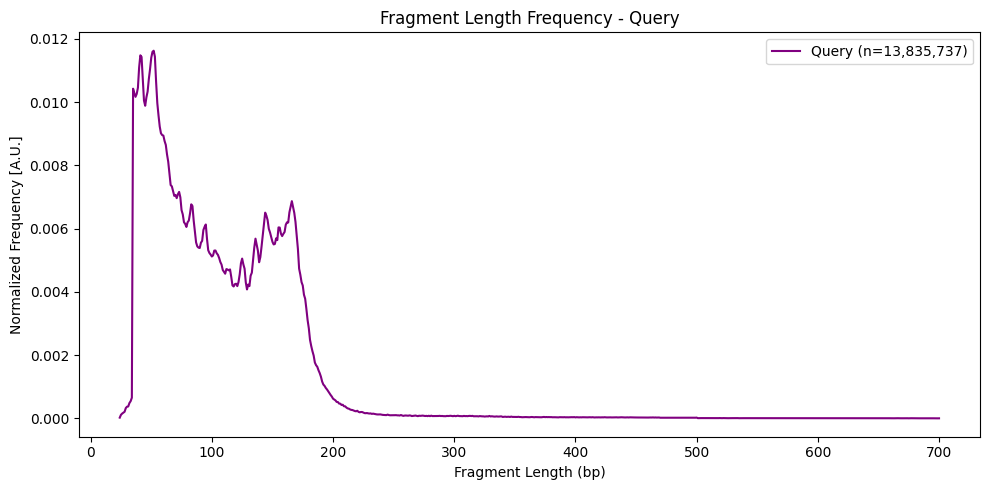

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Explicitly set column data types to avoid warnings
query = pd.read_csv(
    'query.bed',
    sep='\t',
    header=None,
    dtype={0: str, 1: int, 2: int, 3: str, 4: str, 5: str},  # force columns 3,4,5 to be strings
    low_memory=False
)

# Assign column names
query.columns = ['chr', 'start', 'end', 'score', 'dot', 'strand']

# Compute fragment lengths
query['length'] = query['end'] - query['start']
query_series = query['length']

# Calculate normalized frequencies
frag_counts = query_series.value_counts().sort_index()
norm_freq_query = frag_counts / frag_counts.sum()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(norm_freq_query.index, norm_freq_query.values, label=f'Query (n={len(query_series):,})', color='purple')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Frequency - Query")
plt.legend()
plt.tight_layout()
plt.show()



#### **Part 2: Rescaling the Query Distribution**

**Goal**:
To adjust the fragment length distribution of the query dataset so it reflects the shape of a provided reference distribution.

**Steps**:

1. **Load Reference Data**
   Read the `reference.hist` file, which contains fragment lengths and their associated frequencies. Normalize the frequencies so they sum to 1, turning them into a probability distribution.

2. **Compare Distributions**
   Plot both the original (normalized) query distribution and the reference distribution to assess their differences visually.

3. **Organize Query Fragments**
   Group query fragments by length into a dictionary:

   * **Key**: Fragment length
   * **Value**: List of fragments of that length
     This enables quick and efficient access during subsampling.

4. **Define Target Dataset Size**
   Set the size of the rescaled dataset—e.g., 30% of the total query fragments. This determines how many fragments will be retained overall.

5. **Subsample Based on Reference Frequencies**
   For each fragment length in the reference distribution:

   * If the query contains fragments of that length, sample a number proportional to the reference frequency.
   * The number sampled is scaled according to the target dataset size and capped at the number of available fragments of that length.

6. **Recalculate and Plot Final Distribution**
   Compute the frequency distribution of the subsampled fragments, normalize it, and plot it alongside the original query and reference distributions to show the alignment after rescaling.


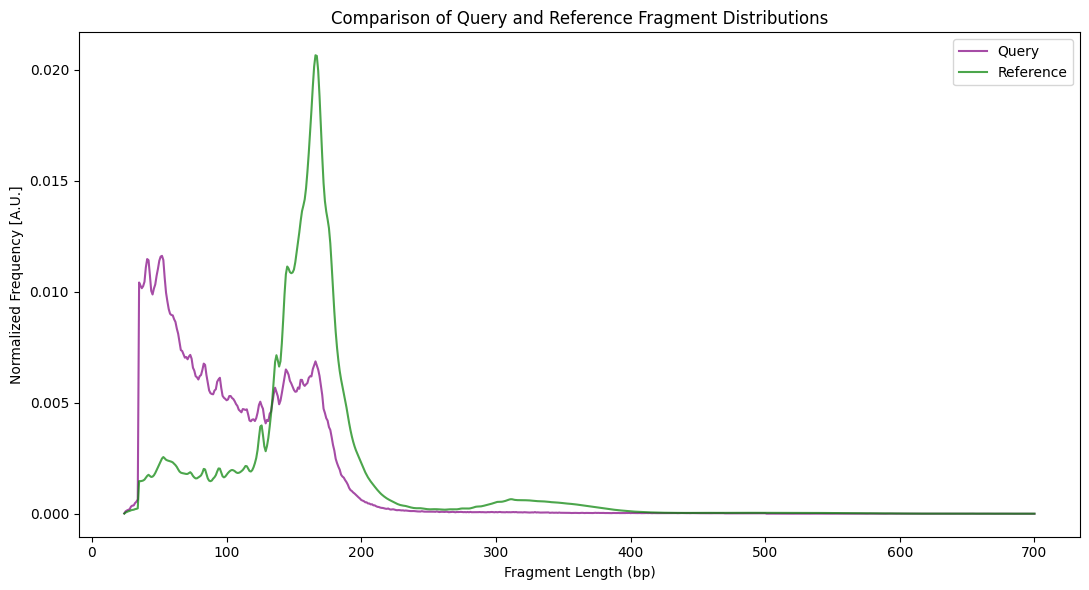

In [7]:

# Load reference.hist using your method
reference = pd.read_csv('reference.hist', sep='\t', header=None)
reference.columns = ['length', 'freq']
reference['length'] = reference['length'].astype(int)
reference_freq = reference.set_index('length')['freq'].sort_index()
reference_freq = reference_freq / reference_freq.sum()  # Normalize

# Plot query vs reference
plt.figure(figsize=(11, 6))
plt.plot(norm_freq_query.index, norm_freq_query.values, label='Query', alpha=0.7, color='purple')
plt.plot(reference_freq.index, reference_freq.values, label='Reference', alpha=0.7, color='green')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Comparison of Query and Reference Fragment Distributions")
plt.legend()
plt.tight_layout()
plt.show()

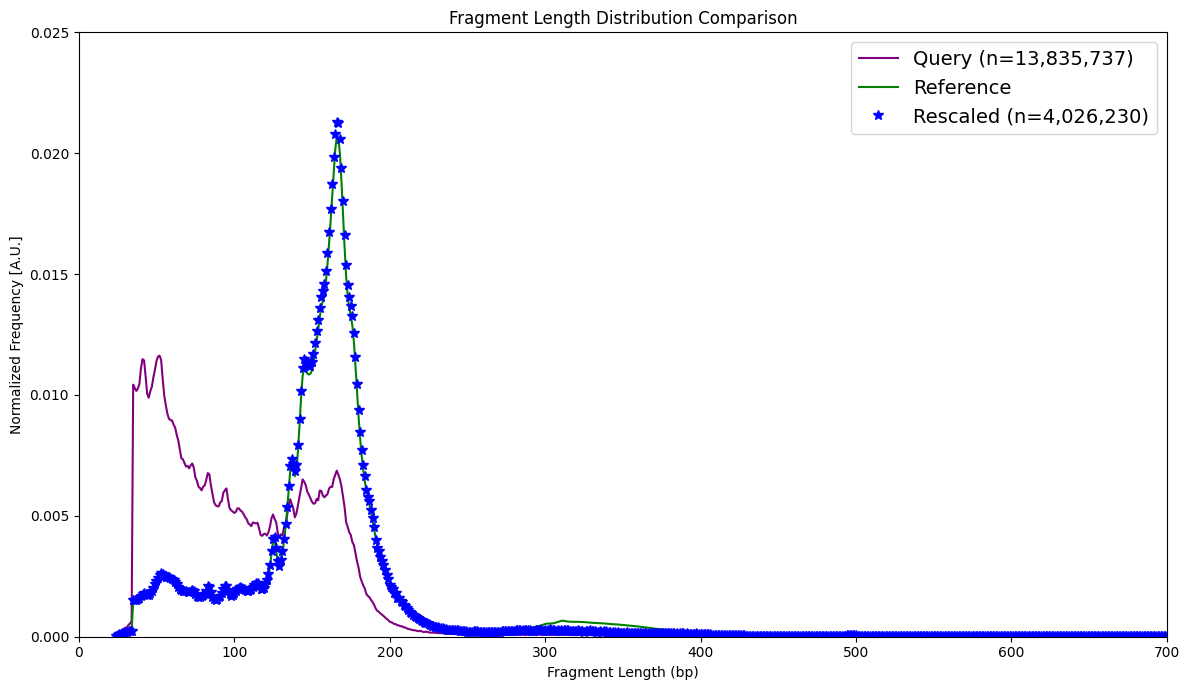

In [11]:
# Group fragments by length for subsampling
fragment_groups = defaultdict(list)
for length in query_series:
    fragment_groups[length].append(length)

# Rescale target
target_size = int(len(query_series) * 0.3)
rescaled_pool = []

# Subsampling based on reference distribution
for length, target_frac in reference_freq.items():
    if length in fragment_groups:
        available_pool = fragment_groups[length]
        desired_n = int(target_frac * target_size)
        rescaled_pool.extend(random.sample(available_pool, min(desired_n, len(available_pool))))

# Plot rescaled vs original vs reference
rescaled_series = pd.Series(rescaled_pool)
rescaled_counts = rescaled_series.value_counts().sort_index()
norm_rescaled = rescaled_counts / rescaled_counts.sum()
plt.figure(figsize=(12, 7))
plt.plot(norm_freq_query.index, norm_freq_query.values, label=f'Query (n={len(query_series):,})', color='purple')
plt.plot(reference_freq.index, reference_freq.values, label='Reference', color='green')
plt.plot(norm_rescaled.index, norm_rescaled.values, '*', label=f'Rescaled (n={len(rescaled_pool):,})',
         color='blue', markersize=7)

plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution Comparison")
plt.xlim(0, 700)
plt.ylim(0, 0.025)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("rescaled_prediction.png")
plt.show()